# Bank Dataset Project

### Import Libraries

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import and Understand Raw Dataset

In [58]:
df = pd.read_csv('bank-data-raw.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

### Preview Dataset

In [59]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0,1,1,1,"101,349",1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,"83,808",1,0,1,"112,543",0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,"159,661",3,1,0,"113,932",1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0,2,0,0,"93,827",0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,"125,511",1,1,1,"79,084",0,0,5,GOLD,425


In [60]:
# Check Geography for unique values
print(df['Geography'].unique())

['France' 'Spain' 'Germany']


### Quality Issue Report

In [61]:
def data_quality_report(df):
    report = {
        'total_records': len(df),
        'duplicate_rows': df.duplicated().sum(),
        'missing_values': df.isnull().sum().to_dict()
    }
    return report

df_report = data_quality_report(df)
print("\n --- Data Quality Report ---")
for key, value in df_report.items():
    print(f"{key.replace('_', ' ').title()}: {value}")


 --- Data Quality Report ---
Total Records: 10000
Duplicate Rows: 0
Missing Values: {'RowNumber': 0, 'CustomerId': 0, 'Surname': 0, 'CreditScore': 0, 'Geography': 0, 'Gender': 0, 'Age': 0, 'Tenure': 0, 'Balance': 0, 'NumOfProducts': 0, 'HasCrCard': 0, 'IsActiveMember': 0, 'EstimatedSalary': 0, 'Exited': 0, 'Complain': 0, 'Satisfaction Score': 0, 'Card Type': 0, 'Point Earned': 0}


### Clean and Manipulate Dataframe

In [62]:
# Create copy for cleaning and manipulation
df_clean = df.copy()

# Drop unecessary columns (row numbers)
df_clean.drop(['RowNumber'], axis = 1, inplace=True)

# Update CustomerID to string type
df_clean['CustomerId'] = df_clean['CustomerId'].astype(str)

# Standardized column names (no spaces)
df_clean.columns = df_clean.columns.str.strip().str.replace(' ', '')

# Change geography to US States
geo = {
    'France': 'West Virginia',
    'Spain': 'Virginia',
    'Germany': 'North Carolina'
}
df_clean['Geography'] = df_clean['Geography'].replace(geo)

# Update specific columns to boolean values
bool_val = ['HasCrCard', 'IsActiveMember', 'Exited', 'Complain']
df_clean[bool_val] = df_clean[bool_val].astype(bool)

# Check updated dataset
print(df_clean.head())
print(df_clean.info())

  CustomerId   Surname  CreditScore      Geography  Gender  Age  Tenure  \
0   15634602  Hargrave          619  West Virginia  Female   42       2   
1   15647311      Hill          608       Virginia  Female   41       1   
2   15619304      Onio          502  West Virginia  Female   42       8   
3   15701354      Boni          699  West Virginia  Female   39       1   
4   15737888  Mitchell          850       Virginia  Female   43       2   

   Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited  \
0        0              1       True            True          101,349    True   
1   83,808              1      False            True          112,543   False   
2  159,661              3       True           False          113,932    True   
3        0              2      False           False           93,827   False   
4  125,511              1       True            True           79,084   False   

   Complain  SatisfactionScore CardType  PointEarned  
0      

### Quick Summary and Information

In [63]:
pd.options.display.float_format = '{:,.0f}'.format
df_clean.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,SatisfactionScore,PointEarned
count,"10,000","10,000","10,000","10,000","10,000","10,000","10,000","10,000"
mean,651,39,5,"76,486",2,"100,090",3,607
std,97,10,3,"62,397",1,"57,510",1,226
min,350,18,0,0,1,12,1,119
25%,584,32,3,0,1,"51,002",2,410
50%,652,37,5,"97,199",1,"100,194",3,605
75%,718,44,7,"127,644",2,"149,388",4,801
max,850,92,10,"250,898",4,"199,992",5,"1,000"


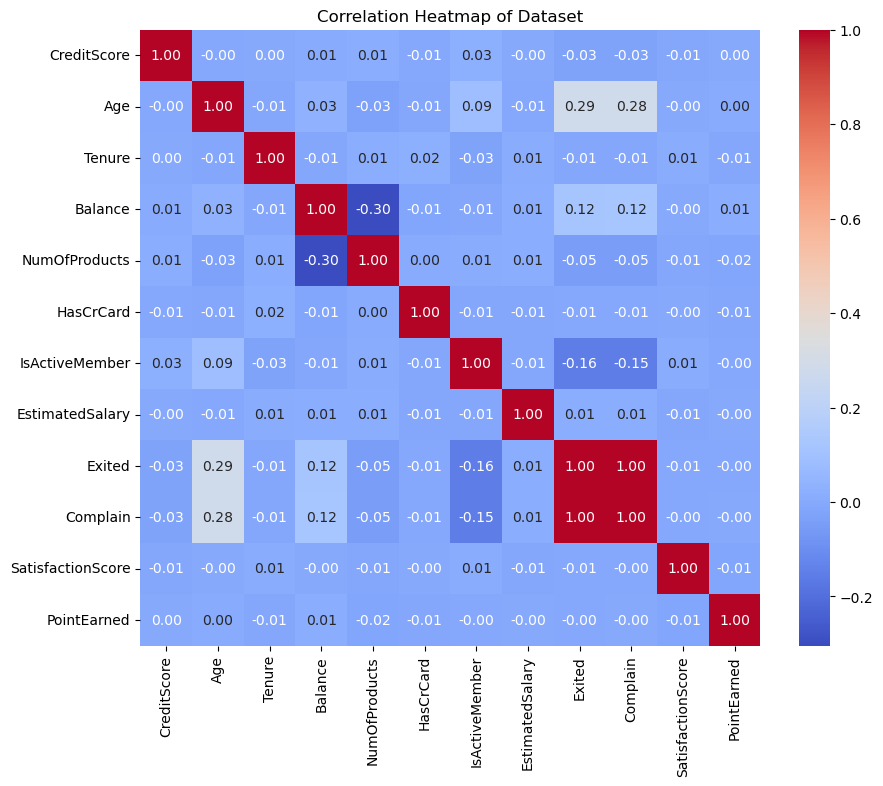

In [64]:
# Find correlation between features for developing churn dashboard
correlation = df_clean.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Dataset')
plt.show()

### Export Cleaned Data

In [65]:
# Save cleaned dataset to new csv file
file_name = 'bank-data-clean.csv'
df_clean.to_csv(file_name, index=False)

### Validation and Comparison Report

In [66]:
print(f'Original Records: {len(df)}')
print(f'Clean records: {len(df_clean)}')
print(f'Records removed: {len(df) - len(df_clean)}')

Original Records: 10000
Clean records: 10000
Records removed: 0
